# UBER DATA ANALYSIS

# IMPORTING LIBRARIES

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET

In [238]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Uber_dataset\UberDataset.csv")

In [240]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


# DATA INVESTIGATION

In [243]:
df.shape

(1156, 7)

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


# DATA EXPLORATION AND PREPROCESSING

### MISSING VALUES

In [249]:
df['PURPOSE'].fillna("NOT", inplace = True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_24800\863022960.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PURPOSE'].fillna("NOT", inplace = True)


In [251]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NOT
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


### FORMATTING
### converting START_DATE and END_DATE into datetime format

In [254]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors = 'coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors = 'coerce')

In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  421 non-null    datetime64[ns]
 1   END_DATE    420 non-null    datetime64[ns]
 2   CATEGORY    1155 non-null   object        
 3   START       1155 non-null   object        
 4   STOP        1155 non-null   object        
 5   MILES       1156 non-null   float64       
 6   PURPOSE     1156 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.3+ KB


### CREATING NEW COLUMNS of DATE AND HOUR
### create new feature representing DATE AND TIME of rides

In [259]:
from datetime import datetime
df['DATE'] = pd.DatetimeIndex(df['START_DATE']).date

In [261]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06


In [263]:
df['TIME'] = pd.DatetimeIndex(df['START_DATE']).hour

In [265]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0


### CREATING NEW COLUMN of CATEGORIES(DAY&NIGHT)
### create new feature representing time of the ride(DAY_NIGHT) - morning, afternoon, evening, night

In [268]:
df['DAY_NIGHT'] = pd.cut(x = df['TIME'], bins = [0, 10, 15, 19, 24], labels = ['MORNING', 'AFTERNOON', 'EVENING', 'NIGHT'])

In [270]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY_NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,NIGHT
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,MORNING
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,NIGHT
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,EVENING
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,AFTERNOON


In [272]:
df.dropna(inplace = True)

In [274]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY_NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,NIGHT
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,MORNING
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,NIGHT
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,EVENING
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,AFTERNOON
...,...,...,...,...,...,...,...,...,...,...
1043,2016-12-12 13:22:00,2016-12-12 13:32:00,Business,Cary,Cary,3.1,Errand/Supplies,2016-12-12,13.0,AFTERNOON
1044,2016-12-12 13:36:00,2016-12-12 13:51:00,Business,Cary,Apex,4.4,Meal/Entertain,2016-12-12,13.0,AFTERNOON
1045,2016-12-12 14:26:00,2016-12-12 14:39:00,Business,Apex,Cary,4.7,Customer Visit,2016-12-12,14.0,AFTERNOON
1046,2016-12-12 17:51:00,2016-12-12 18:01:00,Business,Cary,Morrisville,3.0,Meal/Entertain,2016-12-12,17.0,EVENING


In [276]:
df.describe()

,START_DATE,END_DATE,MILES,TIME
count,413,413,413.000000,413.000000
mean,2016-07-01 16:00:42.711864320,2016-07-01 16:20:05.230024192,9.120823,15.222760
min,2016-01-01 21:11:00,2016-01-01 21:17:00,0.500000,1.000000
25%,2016-03-12 09:13:00,2016-03-12 09:22:00,2.700000,12.000000
50%,2016-07-04 18:23:00,2016-07-04 18:49:00,5.700000,16.000000
75%,2016-10-11 01:27:00,2016-10-11 02:08:00,9.900000,18.000000
max,2016-12-12 20:48:00,2016-12-12 20:57:00,174.200000,23.000000
std,NaN,NaN,16.517267,4.265322


# DATA VISUALIZATION

## IN WHICH CATEGORY DO PEOPLE BOOK THE MOST UBER RIDES?
## FOR WHICH PURPOSE DO PEOPLE BOOK THE MOST UBER RIDES?

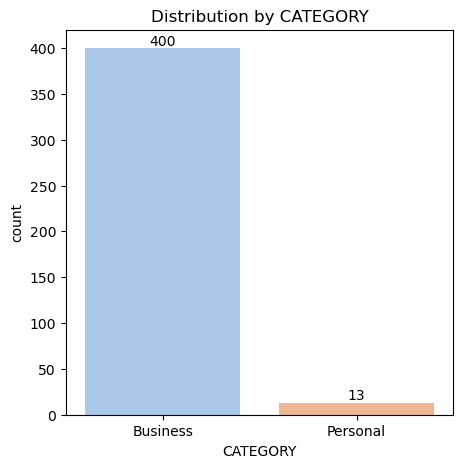

In [367]:
plt.figure(figsize=(5,5))
lab = sns.countplot(data=df, x= 'CATEGORY', hue = 'CATEGORY', palette = 'pastel')
for i in lab.containers:
    lab.bar_label(i)
    
plt.title("Distribution by CATEGORY")

plt.show()

#palette='Set1'       # bright
#palette='Set2'       # soft
#palette='husl'       # highly distinct
#palette='pastel'     # pastel
#palette='viridis'    # gradient

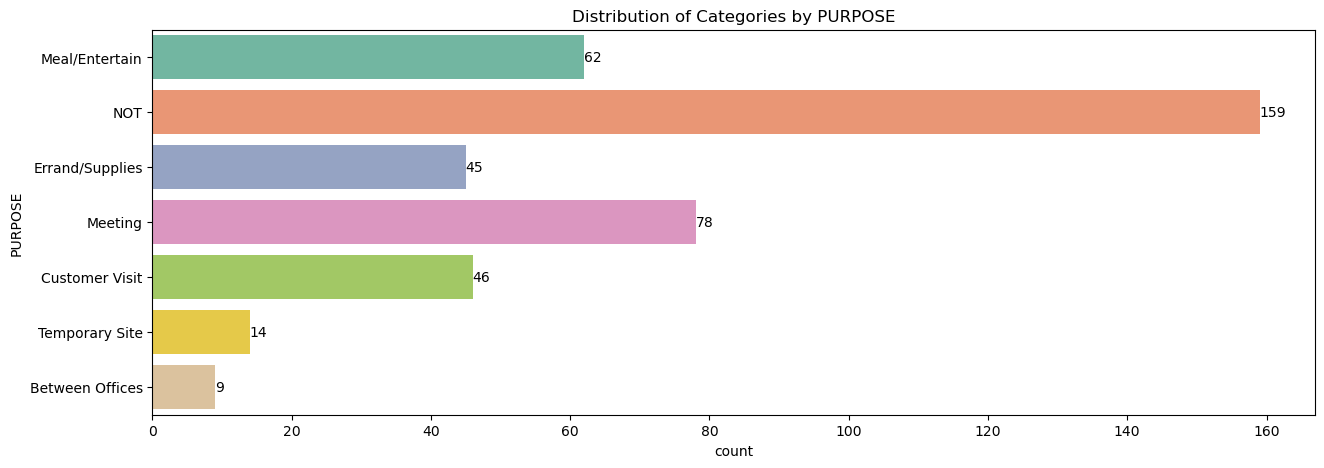

In [365]:
plt.figure(figsize=(15,5))

ax = sns.countplot(
    data=df,
    y='PURPOSE',
    hue='PURPOSE',
    palette='Set2',
    legend=False
)
for i in ax.containers:
    ax.bar_label(i)

plt.title("Distribution of Categories by PURPOSE")
plt.xlabel("count")
plt.ylabel("PURPOSE")

plt.show()

### AT WHAT TIME PEOPLE BOOK CABS THE MOST FROM UBER?

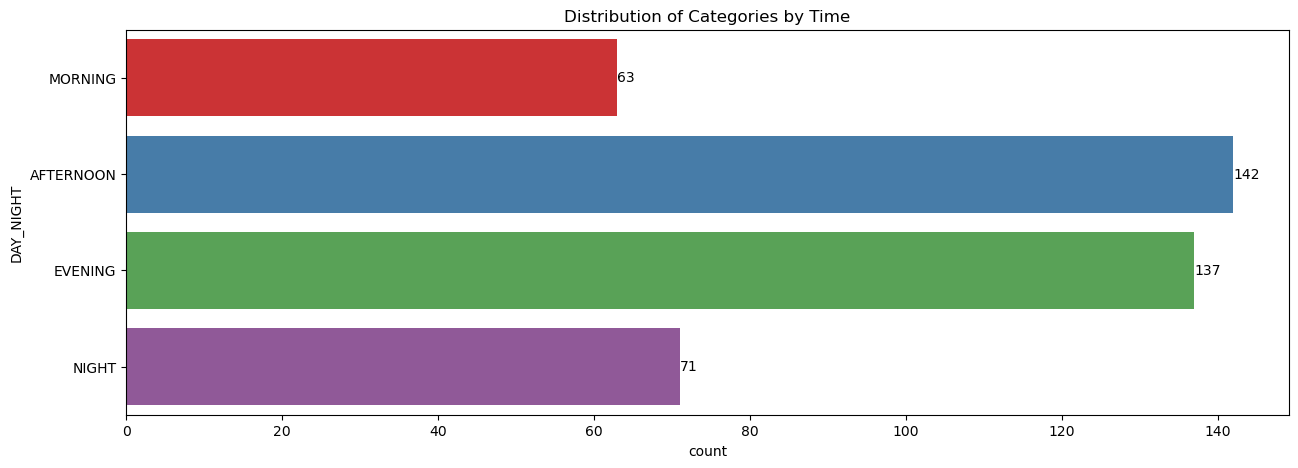

In [382]:
plt.figure(figsize=(15,5))
dn = sns.countplot(data = df, y ='DAY_NIGHT', hue = 'DAY_NIGHT', palette = 'Set1')
for i in dn.containers:
    dn.bar_label(i)

plt.title('Distribution of Categories by Time')

plt.show()

### IN WHICH MONTHS DO PEOPLE BOOK UBER RIDES THE MOST?

### create new feature representing month of the ride

In [288]:
df['MONTH_OF_THE_RIDE'] = df['START_DATE'].apply(lambda i : i.month)
month_label = {1.0: 'Jan', 2.0: 'Feb', 3.0: 'Mar', 4.0: 'April', 5.0: 'May', 6.0: 'June', 7.0: 'July', 8.0: 'Aug', 9.0: 'Sep', 10.0: 'Oct', 11.0: 'Nov', 12.0: 'Dec'}
df['MONTH_OF_THE_RIDE'] = df['MONTH_OF_THE_RIDE'].map(month_label)

### create new feature representing day (week) of the ride

In [290]:
df['DAY_OF_THE_RIDE'] = df['START_DATE'].apply(lambda i : i.weekday())
day_label = {0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

df['DAY_OF_THE_RIDE'] = df['DAY_OF_THE_RIDE'].map(day_label)

In [292]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY_NIGHT,MONTH_OF_THE_RIDE,DAY_OF_THE_RIDE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,NIGHT,Jan,Fri
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,MORNING,Jan,Sat
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,NIGHT,Jan,Sat
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,EVENING,Jan,Tues
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,AFTERNOON,Jan,Wed
...,...,...,...,...,...,...,...,...,...,...,...,...
1043,2016-12-12 13:22:00,2016-12-12 13:32:00,Business,Cary,Cary,3.1,Errand/Supplies,2016-12-12,13.0,AFTERNOON,Dec,Mon
1044,2016-12-12 13:36:00,2016-12-12 13:51:00,Business,Cary,Apex,4.4,Meal/Entertain,2016-12-12,13.0,AFTERNOON,Dec,Mon
1045,2016-12-12 14:26:00,2016-12-12 14:39:00,Business,Apex,Cary,4.7,Customer Visit,2016-12-12,14.0,AFTERNOON,Dec,Mon
1046,2016-12-12 17:51:00,2016-12-12 18:01:00,Business,Cary,Morrisville,3.0,Meal/Entertain,2016-12-12,17.0,EVENING,Dec,Mon


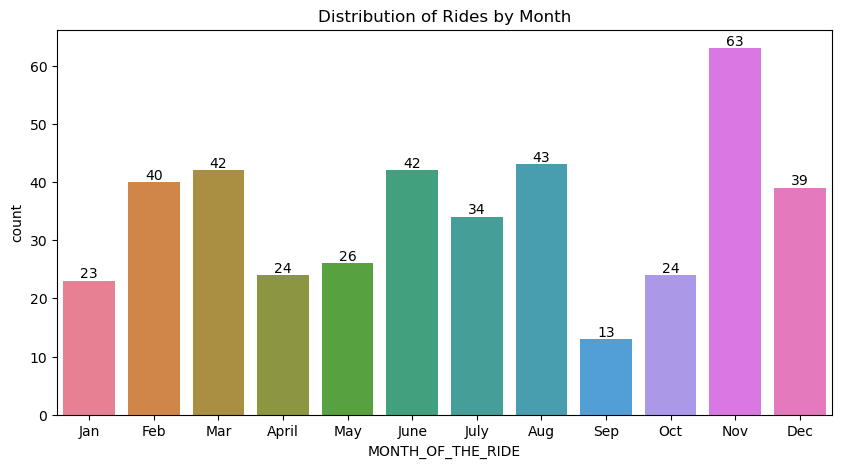

In [361]:
plt.figure(figsize=(10,5))
mo = sns.countplot(data = df, x ='MONTH_OF_THE_RIDE', hue = 'MONTH_OF_THE_RIDE', palette = 'husl')
for i in mo.containers:
    mo.bar_label(i)

plt.title('Distribution of Rides by Month')

plt.show()

### ON WHICH DAYS OF THE WEEK DO PEOPLE BOOK UBER RIDES THE MOST?

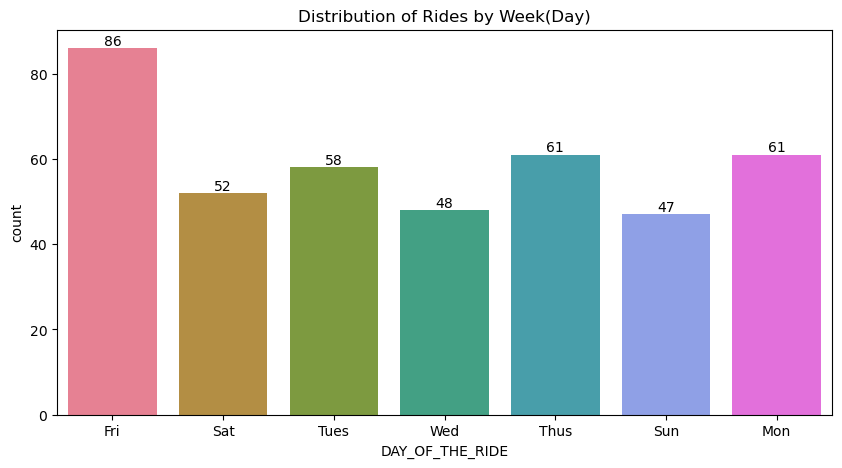

In [359]:
plt.figure(figsize=(10,5))
dy = sns.countplot(data = df, x ='DAY_OF_THE_RIDE', hue = 'DAY_OF_THE_RIDE', palette = 'husl')
for i in dy.containers:
    dy.bar_label(i)

plt.title('Distribution of Rides by Week(Day)')

plt.show()

### IN WHICH MONTHS DO PEOPLE BOOK UBER RIDES LESS FREQUENTLY?

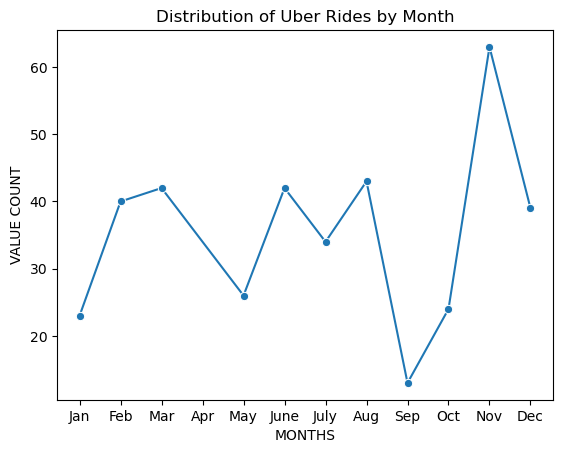

In [353]:
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'June',
    'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

df1 = (
    df['MONTH_OF_THE_RIDE']
    .value_counts()
    .reindex(month_order)
    .reset_index()
)

df1.columns = ['MONTHS', 'VALUE_COUNT']

p = sns.lineplot(
    data=df1,
    x='MONTHS',
    y='VALUE_COUNT',
    marker='o'
)

p.set(
    xlabel='MONTHS',
    ylabel='VALUE COUNT',
    title='Distribution of Uber Rides by Month'
)

plt.show()

### HOW MANY MILES DO PEOPLE USUALLY BOOK A CAB FOR THROUGH UBER?

<Axes: ylabel='MILES'>

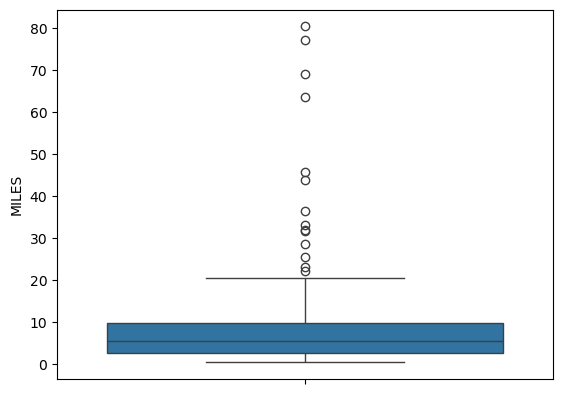

In [333]:
sns.boxplot(df[df['MILES']<100]['MILES'])

<Axes: ylabel='MILES'>

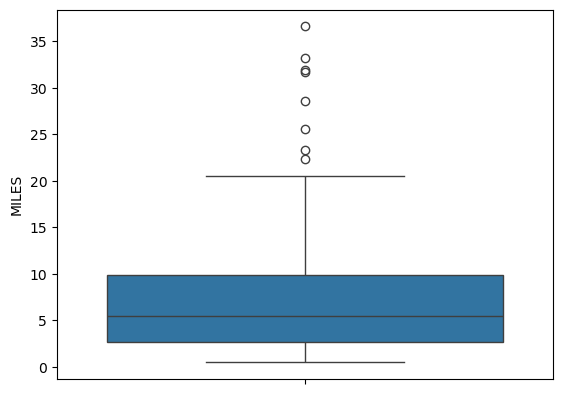

In [335]:
sns.boxplot(df[df['MILES']<40]['MILES'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_24800\2145299684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['MILES']<40]['MILES'])


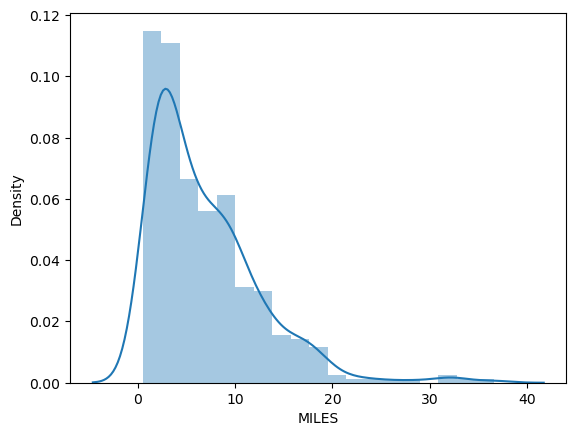

In [380]:
sns.distplot(df[df['MILES']<40]['MILES'])
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_24800\224525000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, y = "START", palette = "Blues_d")


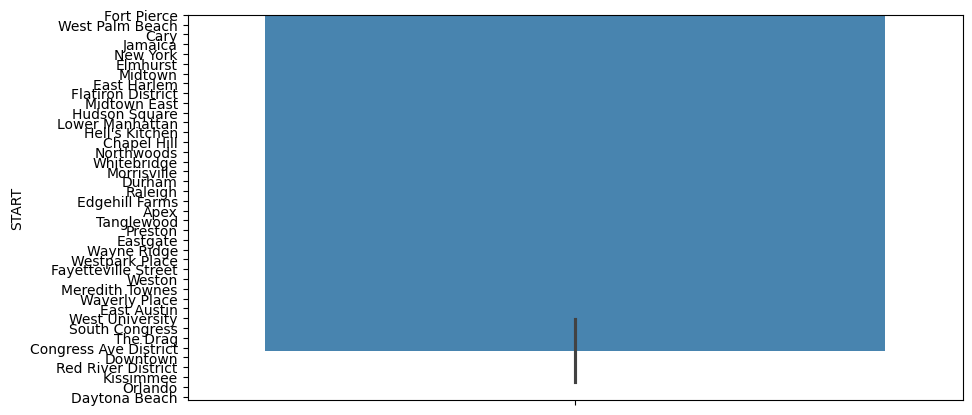

In [370]:
plt.figure(figsize = (10,5))
sns.barplot(data = df, y = "START", palette = "Blues_d")

plt.show()

In [378]:
# Top 10 locations for START
temp = df['START'].value_counts().nlargest(10).reset_index()
sns.barplot(data=temp, y='START', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 START Locations')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_24800\2191129178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


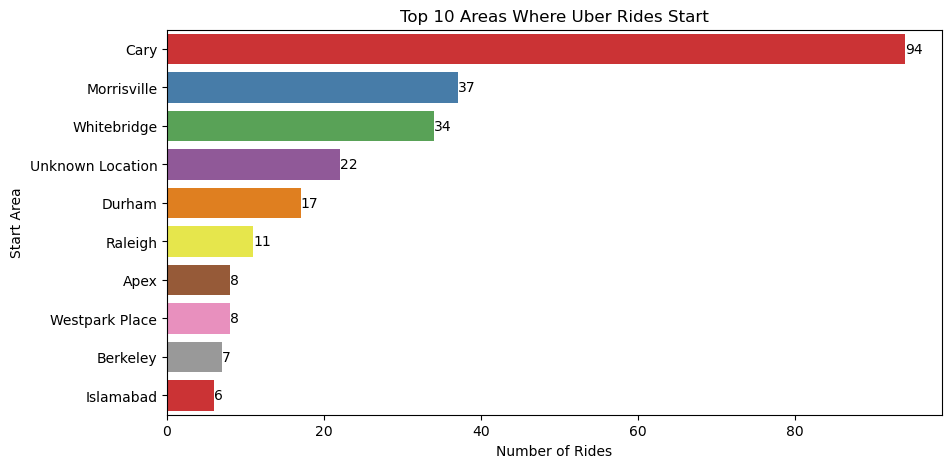

In [396]:
top_start = df["START"].value_counts().head(10)

plt.figure(figsize=(10, 5))

ax1 = sns.barplot(
    x=top_start.values,
    y=top_start.index, palette = "Set1"
)
for i, value in enumerate(top_start.values):
    ax1.text(value, i, str(value), va="center")

plt.title("Top 10 Areas Where Uber Rides Start")
plt.xlabel("Number of Rides")
plt.ylabel("Start Area")

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_24800\3019647725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Text(0, 0.5, 'Stop Area')

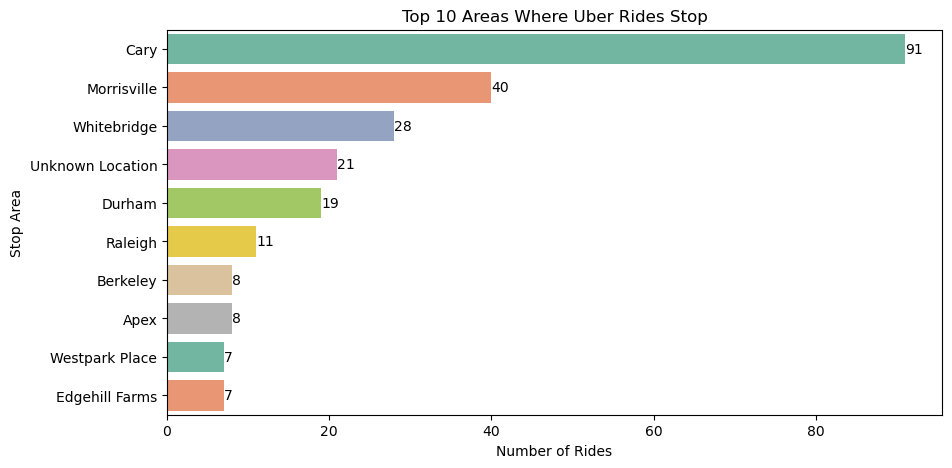

In [394]:
top_stop = df["STOP"].value_counts().head(10)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=top_stop.values,
    y=top_stop.index, palette = "Set2"
)

for i, value in enumerate(top_stop.values):
    ax.text(value, i, str(value), va="center")

plt.title("Top 10 Areas Where Uber Rides Stop")
plt.xlabel("Number of Rides")
plt.ylabel("Stop Area")